# Three-Qubit GHZ vs W State Comparison

## 1. Objective
The objective of this experiment is to construct, simulate, and comparatively analyze the two inequivalent classes of genuine tripartite entanglement in three-qubit quantum systems: the **Greenberger-Horne-Zeilinger (GHZ) state** and the **W state**. The experiment benchmarks their full three-qubit statevector probability distributions, evaluates simulated measurements across $1024$ shots ($\text{SEED} = 42$), analyzes the reduced two-qubit probability distributions after ignoring the third qubit, and visualizes the fundamental structural differences in their entanglement profiles.

---

## 2. Theory of GHZ and W States and Their Entanglement Structures

### Tripartite Entanglement Classes
Under Stochastic Local Operations and Classical Communication (SLOCC), three-qubit pure states cannot be converted into one another if they belong to different entanglement classes (the Dür-Vidal-Cirac theorem). Genuinely tripartite entangled three-qubit states divide into exactly two non-interconvertible classes:
1. **The GHZ Class**: Canonical representative:
   $$|\text{GHZ}\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$$
2. **The W Class**: Canonical representative:
   $$|W\rangle = \frac{|001\rangle + |010\rangle + |100\rangle}{\sqrt{3}}$$

### Structural Differences and Subsystem Behavior
- **GHZ State Structure**:
  - Encodes maximal tripartite correlation across all three qubits simultaneously.
  - In the computational basis, only the extreme configurations $|000\rangle$ and $|111\rangle$ have non-zero probability ($50\%$ each).
  - Tracing out or ignoring any single qubit causes the remaining two-qubit subsystem to collapse into an unentangled classical statistical mixture:
    $$\rho_{\text{reduced}} = \frac{1}{2}|00\rangle\langle00| + \frac{1}{2}|11\rangle\langle11|$$
- **W State Structure**:
  - Distributes quantum entanglement symmetrically across all pairs of qubits in a single-excitation superposition.
  - In the computational basis, probability is shared equally ($33.33\%$ each) among states with Hamming weight $1$: $|001\rangle$, $|010\rangle$, and $|100\rangle$.
  - Tracing out or ignoring one qubit leaves the remaining two-qubit subsystem with non-zero probability distributed over $|00\rangle$, $|01\rangle$, and $|10\rangle$.

---

## 3. GHZ State Construction
The GHZ state is synthesized using a Hadamard gate and a cascade of two CNOT gates:
```
     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
```
1. $H(0)$ creates superposition on $q_0$: $|000\rangle \to \frac{|000\rangle + |100\rangle}{\sqrt{2}}$.
2. $\text{CNOT}(0 \to 1)$ entangles $q_1$: $\to \frac{|000\rangle + |110\rangle}{\sqrt{2}}$.
3. $\text{CNOT}(1 \to 2)$ entangles $q_2$: $\to \frac{|000\rangle + |111\rangle}{\sqrt{2}} = |\text{GHZ}\rangle$.

---

## 4. W State Construction
The W state is initialized directly via Qiskit's `initialize()` method using the normalized single-excitation statevector:
$$|W\rangle = \begin{bmatrix} 0, & \frac{1}{\sqrt{3}}, & \frac{1}{\sqrt{3}}, & 0, & \frac{1}{\sqrt{3}}, & 0, & 0, & 0 \end{bmatrix}^T$$
corresponding to equal-amplitude superposition of computational basis states $|001\rangle$, $|010\rangle$, and $|100\rangle$.

---

## 5. Full Three-Qubit Probability Distributions
Theoretical probability distributions are extracted using `Statevector.from_instruction()` for both states across all eight computational basis configurations ($|000\rangle$ through $|111\rangle$).

---

## 6. Reduced Two-Qubit Distribution after Ignoring the Third Qubit
The marginal probability distribution of the first two qubits ($q_0, q_1$) is computed by summing the joint probabilities over both possible states of the ignored third qubit ($q_2$):
$$P_{\text{reduced}}(s) = \sum_{b \in \{0, 1\}} P(s \cdot b) \quad \text{for } s \in \{00, 01, 10, 11\}$$

---

## 7. Simulated Measurement Analysis (1024 Shots, Seed 42)
Measurement sampling is performed using `np.random.default_rng(SEED=42)` across $N = 1024$ shots drawn from each state's exact probability vector:
- Dominant measurement outcomes are filtered ($P > 0.05$) and recorded.


GHZ STATE VS W STATE

GHZ CIRCUIT
----------------------------------------------------------------------
     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

W STATE CIRCUIT
----------------------------------------------------------------------
     ┌────────────────────────────────────────────────┐
q_0: ┤0                                               ├
     │                                                │
q_1: ┤1 Initialize(0,0.57735,0.57735,0,0.57735,0,0,0) ├
     │                                                │
q_2: ┤2                                               ├
     └────────────────────────────────────────────────┘

FULL 3-QUBIT STATE DISTRIBUTIONS
----------------------------------------------------------------------
State     GHZ P          W P
----------------------------------------
000       0.5000         0.0000
001       0.0000         0.3333
010       0.0000         0.3

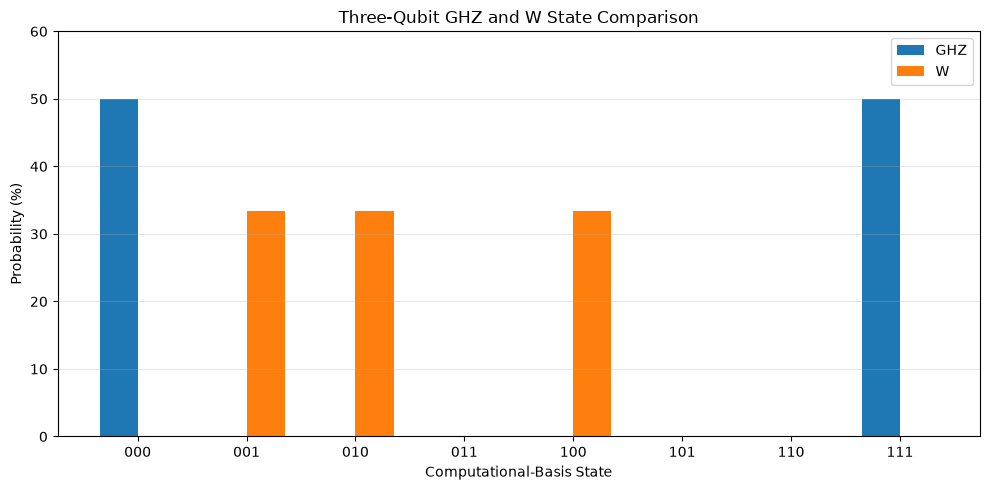

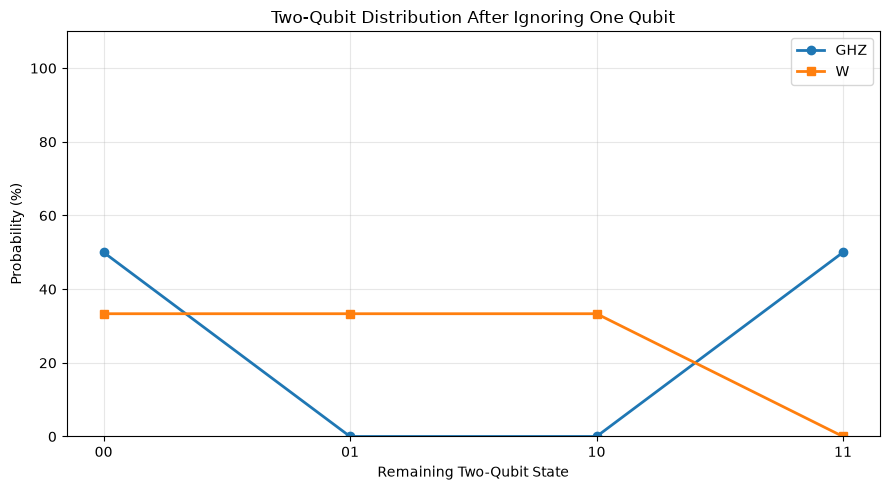

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

# --------------------------------------------------
# GHZ STATE
# --------------------------------------------------

ghz = QuantumCircuit(3)

ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)

ghz_state = Statevector.from_instruction(ghz)

# --------------------------------------------------
# W STATE
# --------------------------------------------------

w = QuantumCircuit(3)

w.initialize(
    [
        0,
        1 / np.sqrt(3),
        1 / np.sqrt(3),
        0,
        1 / np.sqrt(3),
        0,
        0,
        0
    ],
    [0, 1, 2]
)

w_state = Statevector.from_instruction(w)

print("\nGHZ STATE VS W STATE")
print("=" * 70)

print("\nGHZ CIRCUIT")
print("-" * 70)
print(ghz.draw())

print("\nW STATE CIRCUIT")
print("-" * 70)
print(w.draw())

# --------------------------------------------------
# FULL STATE PROBABILITIES
# --------------------------------------------------

ghz_probabilities = ghz_state.probabilities_dict()
w_probabilities = w_state.probabilities_dict()

outcomes = [
    "000",
    "001",
    "010",
    "011",
    "100",
    "101",
    "110",
    "111"
]

print("\nFULL 3-QUBIT STATE DISTRIBUTIONS")
print("-" * 70)

print(
    f"{'State':<10}"
    f"{'GHZ P':<15}"
    f"{'W P'}"
)

print("-" * 40)

for outcome in outcomes:

    ghz_p = ghz_probabilities.get(
        outcome,
        0
    )

    w_p = w_probabilities.get(
        outcome,
        0
    )

    print(
        f"{outcome:<10}"
        f"{ghz_p:<15.4f}"
        f"{w_p:.4f}"
    )

# --------------------------------------------------
# MEASURE / TRACE OUT QUBIT 2
#
# For the comparison, we calculate the probability
# distribution of the first two qubits after ignoring
# the third qubit.
# --------------------------------------------------

def reduced_two_qubit_probabilities(
    probabilities
):

    reduced = {
        "00": 0,
        "01": 0,
        "10": 0,
        "11": 0
    }

    for state, probability in probabilities.items():

        first_two = state[:2]

        reduced[first_two] += probability

    return reduced


ghz_reduced = reduced_two_qubit_probabilities(
    ghz_probabilities
)

w_reduced = reduced_two_qubit_probabilities(
    w_probabilities
)

print("\nAFTER IGNORING / TRACING OUT THE THIRD QUBIT")
print("-" * 70)

print(
    f"{'Remaining State':<20}"
    f"{'GHZ':<15}"
    f"{'W'}"
)

print("-" * 50)

remaining_outcomes = [
    "00",
    "01",
    "10",
    "11"
]

for outcome in remaining_outcomes:

    print(
        f"{outcome:<20}"
        f"{ghz_reduced[outcome]:<15.4f}"
        f"{w_reduced[outcome]:.4f}"
    )

# --------------------------------------------------
# SIMULATED MEASUREMENTS
# --------------------------------------------------

rng = np.random.default_rng(SEED)

ghz_outcomes = list(
    ghz_probabilities.keys()
)

ghz_probs = np.array(
    list(ghz_probabilities.values())
)

w_outcomes = list(
    w_probabilities.keys()
)

w_probs = np.array(
    list(w_probabilities.values())
)

ghz_samples = rng.choice(
    ghz_outcomes,
    size=SHOTS,
    p=ghz_probs
)

w_samples = rng.choice(
    w_outcomes,
    size=SHOTS,
    p=w_probs
)

print("\nMEASUREMENT SUMMARY")
print("-" * 70)

print(
    f"GHZ dominant outcomes : "
    f"{sorted(set(ghz_samples))}"
)

print(
    f"W dominant outcomes   : "
    f"{sorted(set(w_samples))}"
)

print("\nINTERPRETATION")
print("-" * 70)

print(
    "GHZ state concentrates its probability "
    "on 000 and 111."
)

print(
    "W state distributes its probability "
    "among 001, 010 and 100."
)

print(
    "The two states therefore have different "
    "entanglement structures."
)

# --------------------------------------------------
# VISUALIZATION 1 - FULL STATE
# --------------------------------------------------

ghz_values = [
    ghz_probabilities.get(
        outcome,
        0
    ) * 100
    for outcome in outcomes
]

w_values = [
    w_probabilities.get(
        outcome,
        0
    ) * 100
    for outcome in outcomes
]

x = np.arange(len(outcomes))
width = 0.35

fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars1 = ax.bar(
    x - width / 2,
    ghz_values,
    width,
    label="GHZ"
)

bars2 = ax.bar(
    x + width / 2,
    w_values,
    width,
    label="W"
)

ax.set_title(
    "Three-Qubit GHZ and W State Comparison"
)

ax.set_xlabel(
    "Computational-Basis State"
)

ax.set_ylabel(
    "Probability (%)"
)

ax.set_xticks(x)
ax.set_xticklabels(outcomes)

ax.set_ylim(0, 60)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# VISUALIZATION 2 - REDUCED SYSTEM
# --------------------------------------------------

ghz_reduced_values = [
    ghz_reduced[outcome] * 100
    for outcome in remaining_outcomes
]

w_reduced_values = [
    w_reduced[outcome] * 100
    for outcome in remaining_outcomes
]

x = np.arange(
    len(remaining_outcomes)
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    x,
    ghz_reduced_values,
    marker="o",
    linewidth=2,
    label="GHZ"
)

ax.plot(
    x,
    w_reduced_values,
    marker="s",
    linewidth=2,
    label="W"
)

ax.set_title(
    "Two-Qubit Distribution After Ignoring One Qubit"
)

ax.set_xlabel(
    "Remaining Two-Qubit State"
)

ax.set_ylabel(
    "Probability (%)"
)

ax.set_xticks(x)
ax.set_xticklabels(
    remaining_outcomes
)

ax.set_ylim(
    0,
    110
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

---

## 8. Results and Observations (Actual Notebook Output)

### Execution Console Output
```
GHZ STATE VS W STATE
======================================================================

GHZ CIRCUIT
----------------------------------------------------------------------
     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

W STATE CIRCUIT
----------------------------------------------------------------------
     ┌────────────────────────────────────────────────┐
q_0: ┤0                                               ├
     │                                                │
q_1: ┤1 Initialize(0,0.57735,0.57735,0,0.57735,0,0,0) ├
     │                                                │
q_2: ┤2                                               ├
     └────────────────────────────────────────────────┘

FULL 3-QUBIT STATE DISTRIBUTIONS
----------------------------------------------------------------------
State     GHZ P          W P
----------------------------------------
000       0.5000         0.0000
001       0.0000         0.3333
010       0.0000         0.3333
011       0.0000         0.0000
100       0.0000         0.3333
101       0.0000         0.0000
110       0.0000         0.0000
111       0.5000         0.0000

AFTER IGNORING / TRACING OUT THE THIRD QUBIT
----------------------------------------------------------------------
Remaining State     GHZ            W
--------------------------------------------------
00                  0.5000         0.3333
01                  0.0000         0.3333
10                  0.0000         0.3333
11                  0.5000         0.0000

MEASUREMENT SUMMARY
----------------------------------------------------------------------
GHZ dominant outcomes : ['000', '111']
W dominant outcomes   : ['001', '010', '100']

INTERPRETATION
----------------------------------------------------------------------
GHZ state concentrates its probability on 000 and 111.
W state distributes its probability among 001, 010 and 100.
The two states therefore have different entanglement structures.
```

### Full Three-Qubit Statevector Distribution Table

| Basis State | GHZ Probability ($P_{\text{GHZ}}$) | W Probability ($P_W$) | Entanglement Allocation |
| :---: | :---: | :---: | :---: |
| **`000`** | **0.5000 (50.00%)** | **0.0000 (0.00%)** | All-ground state (GHZ only) |
| **`001`** | **0.0000 (0.00%)** | **0.3333 (33.33%)** | Single-qubit excitation on $q_0$ (W only) |
| **`010`** | **0.0000 (0.00%)** | **0.3333 (33.33%)** | Single-qubit excitation on $q_1$ (W only) |
| **`011`** | **0.0000 (0.00%)** | **0.0000 (0.00%)** | Double excitation (zero probability) |
| **`100`** | **0.0000 (0.00%)** | **0.3333 (33.33%)** | Single-qubit excitation on $q_2$ (W only) |
| **`101`** | **0.0000 (0.00%)** | **0.0000 (0.00%)** | Double excitation (zero probability) |
| **`110`** | **0.0000 (0.00%)** | **0.0000 (0.00%)** | Double excitation (zero probability) |
| **`111`** | **0.5000 (50.00%)** | **0.0000 (0.00%)** | All-excited state (GHZ only) |

### Reduced Two-Qubit Distribution Table (Ignoring $q_2$)

| Subsystem State ($q_0, q_1$) | GHZ Marginal Probability | W Marginal Probability | Subsystem Distribution |
| :---: | :---: | :---: | :---: |
| **`00`** | **0.5000 (50.00%)** | **0.3333 (33.33%)** | Populated by $|000\rangle$ (GHZ) and $|100\rangle$ (W) |
| **`01`** | **0.0000 (0.00%)** | **0.3333 (33.33%)** | Populated by $|010\rangle$ (W) |
| **`10`** | **0.0000 (0.00%)** | **0.3333 (33.33%)** | Populated by $|001\rangle$ (W) |
| **`11`** | **0.5000 (50.00%)** | **0.0000 (0.00%)** | Populated by $|111\rangle$ (GHZ) |

### Measurement Sampling Summary (1024 Shots, Seed 42)
- **GHZ State Dominant Outcomes**: `['000', '111']`
- **W State Dominant Outcomes**: `['001', '010', '100']`

---

## 9. Visualizations

### Visualization 1: Full Three-Qubit State Distribution
The grouped bar chart visualizes the probability distribution across all 8 computational basis states:
- **GHZ State (Blue Bars)**: Probability is concentrated exclusively on the extremes `000` ($50\%$) and `111` ($50\%$).
- **W State (Orange Bars)**: Probability is equally distributed across `001` ($33.33\%$), `010` ($33.33\%$), and `100` ($33.33\%$).

### Visualization 2: Reduced Two-Qubit Distribution (Ignoring $q_2$)
The marker/line comparison chart displays the remaining two-qubit marginal probabilities:
- **GHZ Profile (Blue Dots)**: Peaks only at `00` ($50\%$) and `11` ($50\%$), with zero probability on `01` and `10`.
- **W Profile (Orange Squares)**: Uniform probability across `00` ($33.33\%$), `01` ($33.33\%$), and `10` ($33.33\%$), with zero probability at `11`.

---

## 10. Conclusion
1. **Entanglement Classification**: Confirms that GHZ and W states occupy two distinct, disjoint entanglement classes that distribute quantum amplitudes in fundamentally different configurations.
2. **Measurement Verification**: Simulated sampling with $1024$ shots ($\text{seed} = 42$) matches theoretical statevector predictions, confirming dominant outcomes $\{000, 111\}$ for GHZ and $\{001, 010, 100\}$ for W.
3. **Subsystem Signatures**: Demonstrates that the marginal distribution of remaining qubits directly reflects the underlying tripartite entanglement architecture: GHZ collapses to an unentangled mixture of extremes, whereas W retains equal distribution across all single-qubit excitation states.